---

We study the iVi (integrated variance implicit) scheme
of [Abi Jaber (2025)](https://arxiv.org/abs/2412.11264) for the Heston model.

---

## Imports

In [153]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from ivi_scheme import impvol_heston_ivi_scheme
from heston import impvol_heston_charfunc

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234

## The iVi scheme

In [155]:
set_1 = {"V0": 0.006, "a": 17.25 * 0.018, "b": -17.25, "c": 2.95, "rho": -0.68}
set_2 = {"V0": 0.023, "a": 2.15 * 0.057, "b": -2.15, "c": 0.86, "rho": -0.70}
set_3 = {"V0": 0.04, "a": 0.5 * 0.04, "b": -0.5, "c": 1.0, "rho": -0.90}

dict_sets = {"set_1": set_1, "set_2": set_2, "set_3": set_3}

In [156]:
n_disc = 100  # number of time-steps
n_paths = 10**5  # number of Monte Carlo paths
T = 0.1  # maturity
ks = np.linspace(-0.2, 0.1, 101)  # log-moneynesses

In [157]:
params = dict_sets["set_2"]

params_heston = {
    "v": params["V0"],
    "lbd": -params["b"],
    "vbar": -params["a"] / params["b"],
    "nu": params["c"],
    "rho": params["rho"],
}

In [158]:
impvols_hst_cf = impvol_heston_charfunc(ks, T, params_heston)

In [159]:
impvols_hst_ivi = impvol_heston_ivi_scheme(
    ks, T, params_heston, n_disc=n_disc, n_paths=n_paths, seed=SEED
)

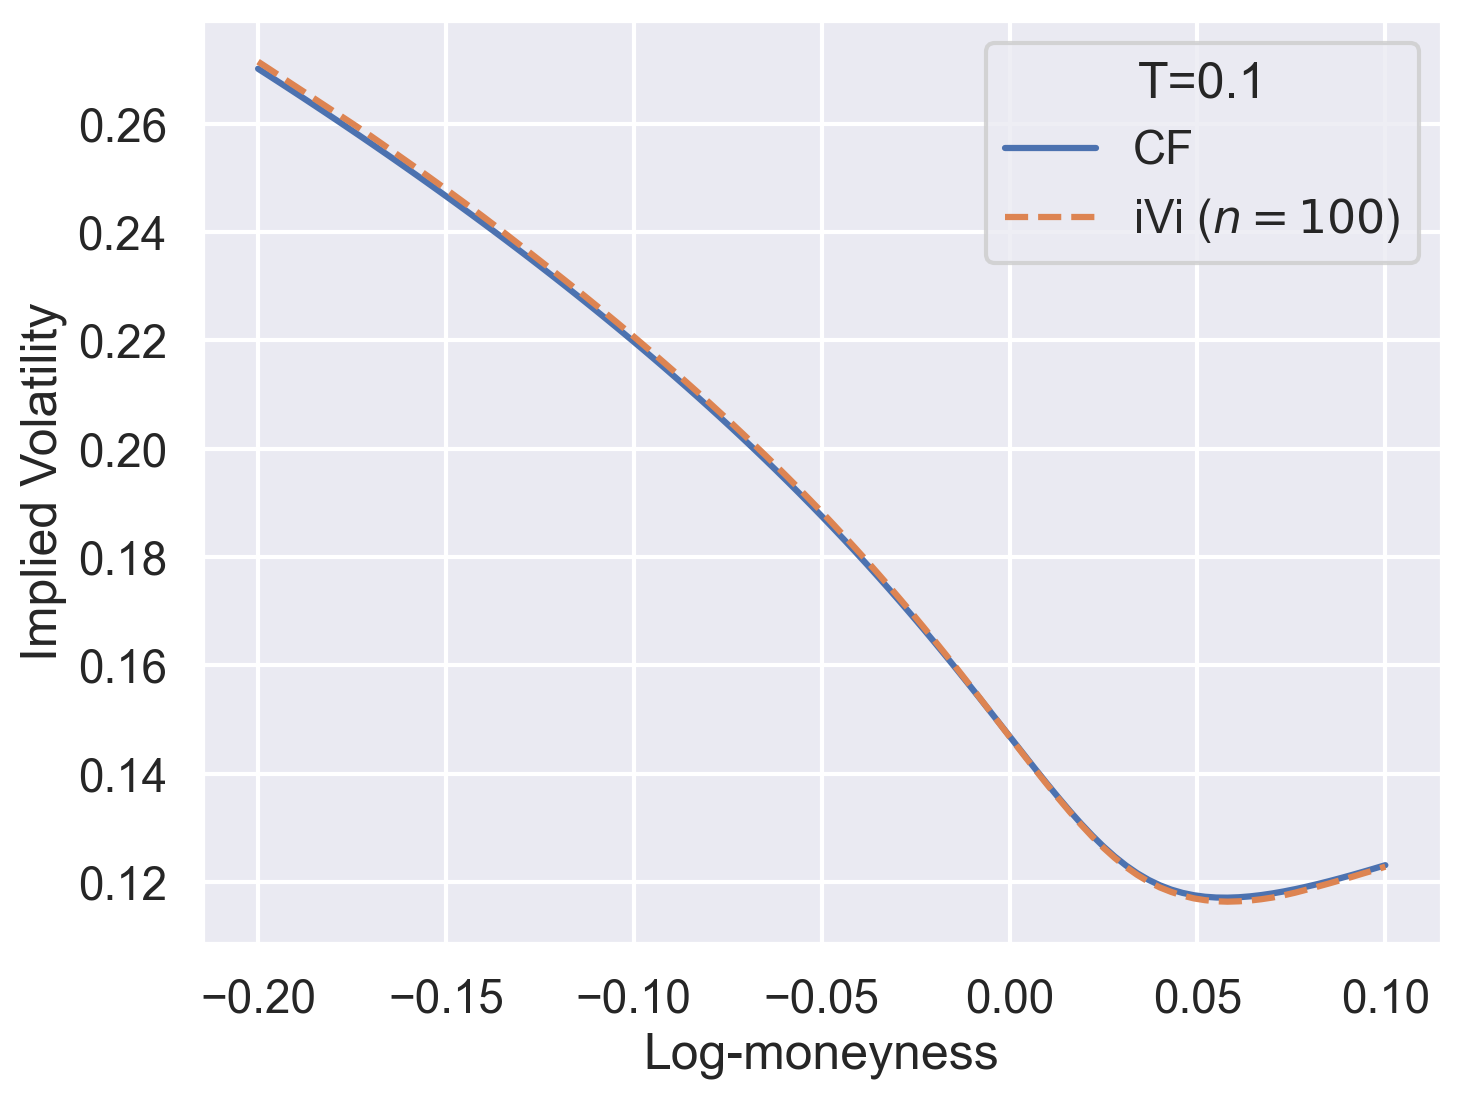

In [160]:
fig, ax = plt.subplots()
ax.plot(ks, impvols_hst_cf, label="CF")
ax.plot(ks, impvols_hst_ivi, "--", label=rf"iVi ($n={n_disc}$)")
ax.legend(title=f"T={T}")
ax.set_xlabel(r"Log-moneyness")
ax.set_ylabel("Implied Volatility")
plt.show()

In [162]:
# TODO: add QE / RSQE scheme to compare.